# BM25 Retrieval Evaluation for Docs and Code

This notebook compares two retrieval mechanisms on two corpora:

- `data/kdk/docs`
- `data/kdk` code (`core` + `map`)

Mechanisms:

- `semantic`: `nomic-embed-text` + Qdrant
- `bm25`: lexical retrieval with a lightweight in-notebook BM25 implementation

The chunk sets are fixed per corpus so the comparison isolates retrieval mechanism rather than chunking.


In [1]:
import json
import math
import re
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from tqdm.auto import tqdm

from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120
print("Imports OK")


Imports OK


In [2]:
ROOT_DIR = Path("..").resolve()
DOCS_DIR = ROOT_DIR / "data" / "kdk" / "docs"
CODE_DIR = ROOT_DIR / "data" / "kdk"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
OLLAMA_URL = "http://localhost:11434"
EMBEDDING_MODEL = "nomic-embed-text"
JUDGE_MODEL = "qwen2.5:7b"

DOCS_COLLECTION = "nb06_docs_semantic"
CODE_COLLECTION = "nb06_code_semantic"
RESET_ARTIFACTS = True

DOCS_TOP_K = 20
CODE_TOP_K = 10
EMBED_BATCH_SIZE = 32
DOCS_MAX_CHARS = 3000
CODE_CHUNK_SIZE = 1200
CODE_CHUNK_OVERLAP = 120
MIN_CODE_SYMBOL_CHARS = 120

DOCS_EVAL_PATH = OUTPUT_DIR / "nb06_docs_eval.json"
CODE_EVAL_PATH = OUTPUT_DIR / "nb06_code_eval.json"

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

print(f"Docs dir: {DOCS_DIR} (exists={DOCS_DIR.exists()})")
print(f"Code dir: {CODE_DIR} (exists={CODE_DIR.exists()})")
print(f"Embedding model: {EMBEDDING_MODEL}")


Docs dir: D:\kalisio\code_rag\data\kdk\docs (exists=True)
Code dir: D:\kalisio\code_rag\data\kdk (exists=True)
Embedding model: nomic-embed-text


In [3]:
def parse_test_questions(path: Path) -> list[dict]:
    text = path.read_text(encoding="utf-8")
    rows = []
    difficulty = "Unknown"
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("## "):
            difficulty = line[3:].strip()
        match = re.match(r"^(\d+)\.\s+(.+)$", line)
        if match:
            rows.append({"question_id": int(match.group(1)), "difficulty": difficulty, "question": match.group(2)})
    return rows


def normalize_repo_path(path: str) -> str:
    return path.replace("\\", "/").strip()


def split_camel_case(token: str) -> list[str]:
    token = re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", token)
    token = token.replace("_", " ").replace("-", " ")
    return [part for part in token.lower().split() if part]


def tokenize_docs(text: str) -> list[str]:
    return re.findall(r"[a-z0-9]+", text.lower())


def tokenize_code(text: str) -> list[str]:
    raw = re.findall(r"[A-Za-z_][A-Za-z0-9_./-]*", text)
    tokens = []
    for token in raw:
        tokens.append(token.lower())
        tokens.extend(split_camel_case(token))
        if "/" in token or "\\" in token or "." in token:
            tokens.extend(part.lower() for part in re.split(r"[\\/._-]+", token) if part)
    return [tok for tok in tokens if tok]


class SimpleBM25:
    def __init__(self, corpus_tokens: list[list[str]], k1: float = 1.5, b: float = 0.75):
        self.corpus_tokens = corpus_tokens
        self.k1 = k1
        self.b = b
        self.doc_count = len(corpus_tokens)
        self.doc_lens = [len(doc) for doc in corpus_tokens]
        self.avgdl = sum(self.doc_lens) / self.doc_count if self.doc_count else 0.0
        self.term_freqs = []
        self.doc_freqs = defaultdict(int)
        for doc in corpus_tokens:
            freqs = Counter(doc)
            self.term_freqs.append(freqs)
            for term in freqs:
                self.doc_freqs[term] += 1
        self.idf = {term: math.log(1 + (self.doc_count - df + 0.5) / (df + 0.5)) for term, df in self.doc_freqs.items()}

    def top_k(self, query_tokens: list[str], k: int) -> list[tuple[int, float]]:
        query_terms = Counter(query_tokens)
        scores = []
        for idx, freqs in enumerate(self.term_freqs):
            dl = self.doc_lens[idx]
            score = 0.0
            for term, qf in query_terms.items():
                tf = freqs.get(term, 0)
                if tf == 0:
                    continue
                idf = self.idf.get(term, 0.0)
                denom = tf + self.k1 * (1 - self.b + self.b * dl / self.avgdl) if self.avgdl else 1.0
                score += qf * idf * ((tf * (self.k1 + 1)) / denom)
            scores.append(score)
        order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
        return [(i, scores[i]) for i in order[:k]]


questions = parse_test_questions(ROOT_DIR / "test_questions_en.md")
print(f"Loaded {len(questions)} docs questions")


Loaded 30 docs questions


In [4]:
from src.chunk_md import chunk_markdown_corpus

docs_chunks = chunk_markdown_corpus(DOCS_DIR, max_chars=DOCS_MAX_CHARS)
for chunk in docs_chunks:
    meta = chunk['metadata']
    chunk['retrieval_text'] = f"source {meta.get('source', '')} title {meta.get('doc_title', '')} section {meta.get('section_title', '')}\n\n{chunk['text']}"
docs_tokens = [tokenize_docs(chunk['retrieval_text']) for chunk in docs_chunks]
docs_bm25 = SimpleBM25(docs_tokens)
print(f"Docs chunks: {len(docs_chunks)}")


Docs chunks: 711


In [5]:
SUPPORTED_CODE_EXTS = {'.js', '.vue', '.mjs', '.cjs'}
EXCLUDE_PARTS = {'docs', 'node_modules', '.git', '__screenshots__'}
CODE_INCLUDE_TOP_LEVEL = {'core', 'map'}
symbol_splitter = RecursiveCharacterTextSplitter(chunk_size=CODE_CHUNK_SIZE, chunk_overlap=CODE_CHUNK_OVERLAP, separators=['\n\n', '\n', ' '])
SYMBOL_PATTERN = re.compile(r'(?m)^(export\s+default\s+async\s+function\s+\w+.*$|export\s+default\s+function\s+\w+.*$|export\s+async\s+function\s+\w+.*$|export\s+function\s+\w+.*$|export\s+class\s+\w+.*$|export\s+const\s+\w+.*$|export\s+let\s+\w+.*$|export\s+var\s+\w+.*$|async\s+function\s+\w+.*$|function\s+\w+.*$|class\s+\w+.*$)')


def should_include_code_file(path: Path) -> bool:
    if path.suffix.lower() not in SUPPORTED_CODE_EXTS:
        return False
    rel = path.relative_to(CODE_DIR)
    if set(rel.parts) & EXCLUDE_PARTS:
        return False
    return rel.parts[0] in CODE_INCLUDE_TOP_LEVEL or rel.parent == Path('.')


def read_code_file(path: Path) -> str:
    return path.read_text(encoding='utf-8', errors='ignore')


def extract_vue_blocks(text: str) -> dict:
    blocks = {}
    for tag in ['template', 'script', 'style']:
        matches = re.findall(rf'<{tag}[^>]*>(.*?)</{tag}>', text, re.DOTALL)
        if matches:
            blocks[tag] = '\n\n'.join(match.strip() for match in matches if match.strip())
    return blocks


def detect_symbol_name(header_line: str) -> str:
    for pattern in [r'export\s+default\s+async\s+function\s+(\w+)', r'export\s+default\s+function\s+(\w+)', r'export\s+async\s+function\s+(\w+)', r'export\s+function\s+(\w+)', r'export\s+class\s+(\w+)', r'export\s+const\s+(\w+)', r'export\s+let\s+(\w+)', r'function\s+(\w+)', r'class\s+(\w+)']:
        match = re.search(pattern, header_line)
        if match:
            return match.group(1)
    return 'module_block'


def split_js_symbols(text: str) -> list[tuple[str, str]]:
    matches = list(SYMBOL_PATTERN.finditer(text))
    if not matches:
        return [('module_block', text.strip())] if text.strip() else []
    rows = []
    if matches[0].start() > 0:
        preamble = text[:matches[0].start()].strip()
        if preamble:
            rows.append(('module_preamble', preamble))
    for i, match in enumerate(matches):
        start = match.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        block = text[start:end].strip()
        if block:
            rows.append((detect_symbol_name(match.group(0).strip()), block))
    return rows


def make_code_meta(path: Path, kind: str, symbol: str = '', block: str = '') -> dict:
    return {'source': normalize_repo_path(str(path.relative_to(CODE_DIR))), 'ext': path.suffix.lower(), 'chunk_kind': kind, 'symbol': symbol, 'block': block}


def chunk_code(path: Path) -> list[dict]:
    text = read_code_file(path)
    rows = []
    if path.suffix.lower() == '.vue':
        blocks = extract_vue_blocks(text)
        script_text = blocks.get('script', '').strip()
        template_text = blocks.get('template', '').strip()
        if script_text:
            for symbol_name, symbol_text in split_js_symbols(script_text):
                if len(symbol_text.strip()) < MIN_CODE_SYMBOL_CHARS:
                    continue
                docs = symbol_splitter.create_documents([symbol_text], metadatas=[make_code_meta(path, 'vue_script_symbol', symbol=symbol_name, block='script')])
                rows.extend({'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip())
        if template_text and len(template_text) >= MIN_CODE_SYMBOL_CHARS:
            docs = symbol_splitter.create_documents([template_text], metadatas=[make_code_meta(path, 'vue_template', block='template')])
            rows.extend({'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip())
    else:
        for symbol_name, symbol_text in split_js_symbols(text):
            if len(symbol_text.strip()) < MIN_CODE_SYMBOL_CHARS:
                continue
            docs = symbol_splitter.create_documents([symbol_text], metadatas=[make_code_meta(path, 'symbol', symbol=symbol_name)])
            rows.extend({'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip())
    return rows


code_files = [path for path in CODE_DIR.rglob('*') if path.is_file() and should_include_code_file(path)]
code_chunks = []
for path in tqdm(code_files, desc='Chunking code corpus'):
    code_chunks.extend(chunk_code(path))
for chunk in code_chunks:
    meta = chunk['metadata']
    chunk['retrieval_text'] = f"source {meta.get('source', '')} symbol {meta.get('symbol', '')} kind {meta.get('chunk_kind', '')} block {meta.get('block', '')}\n\n{chunk['text']}"
code_tokens = [tokenize_code(chunk['retrieval_text']) for chunk in code_chunks]
code_bm25 = SimpleBM25(code_tokens)
print(f"Code files: {len(code_files)}")
print(f"Code chunks: {len(code_chunks)}")


Chunking code corpus:   0%|          | 0/544 [00:00<?, ?it/s]

Code files: 544
Code chunks: 3032


In [6]:
embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_URL)
qdrant = QdrantClient(url=QDRANT_URL)


def reset_nb06() -> None:
    for collection in [DOCS_COLLECTION, CODE_COLLECTION]:
        if qdrant.collection_exists(collection):
            qdrant.delete_collection(collection)
    for path in [DOCS_EVAL_PATH, CODE_EVAL_PATH]:
        if path.exists():
            path.unlink()


def embed_texts(texts: list[str], batch_size: int = EMBED_BATCH_SIZE) -> np.ndarray:
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc='Embedding'):
        vectors.extend(embeddings.embed_documents(texts[start:start + batch_size]))
    return np.array(vectors)


def ingest_semantic(collection_name: str, chunks: list[dict]) -> None:
    vectors = embed_texts([chunk['retrieval_text'] for chunk in chunks])
    if qdrant.collection_exists(collection_name):
        qdrant.delete_collection(collection_name)
    qdrant.create_collection(collection_name=collection_name, vectors_config=VectorParams(size=vectors.shape[1], distance=Distance.COSINE))
    points = [PointStruct(id=i, vector=vectors[i].tolist(), payload={**chunks[i]['metadata'], 'text': chunks[i]['text']}) for i in range(len(chunks))]
    qdrant.upsert(collection_name=collection_name, points=points)


if RESET_ARTIFACTS:
    reset_nb06()
ingest_semantic(DOCS_COLLECTION, docs_chunks)
ingest_semantic(CODE_COLLECTION, code_chunks)
print('Semantic indexes ready')


Embedding:   0%|          | 0/23 [00:00<?, ?it/s]

Embedding:   0%|          | 0/95 [00:00<?, ?it/s]

Semantic indexes ready


In [7]:
DOCS_JUDGE_PROMPT = """You are evaluating retrieval quality for a RAG system.\n\nQuestion:\n{question}\n\nRetrieved chunks:\n{retrieved_chunks}\n\nDetermine the first chunk rank that contains enough information to answer the question directly and faithfully from the retrieved text alone.\n\nRules:\n- A chunk is relevant only if it contains the answer, not just related terminology.\n- If no chunk in the list is sufficient, return null for first_relevant_rank.\n- Also return booleans for has_answer_top1, has_answer_top5, has_answer_top20.\n\nReturn only JSON with keys:\nfirst_relevant_rank, has_answer_top1, has_answer_top5, has_answer_top20, rationale\n"""


def parse_judge_json(text: str) -> dict:
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
        raise


def semantic_retrieve_docs(question: str, k: int = DOCS_TOP_K):
    qvec = embeddings.embed_query(question)
    return qdrant.query_points(collection_name=DOCS_COLLECTION, query=qvec, limit=k, with_payload=True).points


def bm25_retrieve_docs(question: str, k: int = DOCS_TOP_K):
    return docs_bm25.top_k(tokenize_docs(question), k)


def format_docs_points(points, mechanism: str) -> str:
    blocks = []
    for rank, point in enumerate(points, start=1):
        if mechanism == 'semantic':
            payload = point.payload or {}
            score = point.score
            text = payload.get('text', '')
        else:
            idx, score = point
            payload = docs_chunks[idx]['metadata']
            text = docs_chunks[idx]['text']
        blocks.append(f"[Rank {rank}] score={score:.4f}\nSource: {payload.get('source', '')}\nSection: {payload.get('section_title', '')}\nContent:\n{text[:900]}")
    return "\n\n".join(blocks)


def judge_docs(question: str, points, mechanism: str) -> dict:
    prompt = DOCS_JUDGE_PROMPT.format(question=question, retrieved_chunks=format_docs_points(points, mechanism))
    resp = requests.post(f"{OLLAMA_URL}/api/generate", json={'model': JUDGE_MODEL, 'prompt': prompt, 'stream': False, 'format': 'json'}, timeout=120)
    resp.raise_for_status()
    data = parse_judge_json(resp.json().get('response', '').strip())
    rank = data.get('first_relevant_rank')
    data['first_relevant_rank'] = int(rank) if rank is not None else None
    for key in ['has_answer_top1', 'has_answer_top5', 'has_answer_top20']:
        data[key] = bool(data.get(key, False))
    return data


if DOCS_EVAL_PATH.exists() and not RESET_ARTIFACTS:
    docs_eval = json.loads(DOCS_EVAL_PATH.read_text(encoding='utf-8'))
else:
    docs_eval = []
    for q in tqdm(questions, desc='Evaluating docs retrieval'):
        for mechanism in ['semantic', 'bm25']:
            t0 = time.time()
            points = semantic_retrieve_docs(q['question'], DOCS_TOP_K) if mechanism == 'semantic' else bm25_retrieve_docs(q['question'], DOCS_TOP_K)
            retrieval_time = time.time() - t0
            judged = judge_docs(q['question'], points, mechanism)
            docs_eval.append({**q, 'mechanism': mechanism, 'retrieval_time': retrieval_time, 'first_relevant_rank': judged.get('first_relevant_rank'), 'has_answer_top1': judged.get('has_answer_top1', False), 'has_answer_top5': judged.get('has_answer_top5', False), 'has_answer_top20': judged.get('has_answer_top20', False), 'judge_rationale': judged.get('rationale', '')})
    DOCS_EVAL_PATH.write_text(json.dumps(docs_eval, ensure_ascii=False, indent=2), encoding='utf-8')

docs_eval_df = pd.DataFrame(docs_eval)
docs_eval_df['rank_for_metrics'] = docs_eval_df['first_relevant_rank'].fillna(DOCS_TOP_K + 1)
docs_eval_df['reciprocal_rank'] = docs_eval_df['first_relevant_rank'].apply(lambda x: 1 / x if pd.notnull(x) else 0.0)
docs_metrics = docs_eval_df.groupby('mechanism').agg(hit_at_1=('has_answer_top1', 'mean'), hit_at_5=('has_answer_top5', 'mean'), hit_at_20=('has_answer_top20', 'mean'), mean_first_relevant_rank=('rank_for_metrics', 'mean'), median_first_relevant_rank=('rank_for_metrics', 'median'), mrr=('reciprocal_rank', 'mean'), mean_retrieval_time=('retrieval_time', 'mean')).round(3)
docs_metrics


Evaluating docs retrieval:   0%|          | 0/30 [00:00<?, ?it/s]

,hit_at_1,hit_at_5,hit_at_20,mean_first_relevant_rank,median_first_relevant_rank,mrr,mean_retrieval_time
mechanism,,,,,,,
bm25,0.533,0.867,0.867,5.533,1.5,0.587,0.002
semantic,0.767,0.933,0.933,2.333,1.0,0.822,2.315


In [8]:
code_benchmark = [
    {'question_id': 1, 'question': 'Where is createService implemented on the client API?', 'targets': ['core/client/api.js']},
    {'question_id': 2, 'question': 'Which file defines createOfflineService for client-side offline services?', 'targets': ['core/client/api.js']},
    {'question_id': 3, 'question': 'Where is getServicePath implemented?', 'targets': ['core/client/api.js']},
    {'question_id': 4, 'question': 'Which file defines the map defineUserAbilities helper?', 'targets': ['map/common/permissions.js']},
    {'question_id': 5, 'question': 'Where is the useWeather composable implemented?', 'targets': ['map/client/composables/weather.js']},
    {'question_id': 6, 'question': 'Which file defines addQueryParameter and URL-building utilities?', 'targets': ['core/common/utils.js']},
    {'question_id': 7, 'question': 'Where is makeDiacriticPattern implemented?', 'targets': ['core/common/utils.js']},
    {'question_id': 8, 'question': 'Which file defines the GeoTiffGridSource class?', 'targets': ['map/common/geotiff-grid-source.js']},
    {'question_id': 9, 'question': 'Where are PMTiles layers and related schema helpers implemented?', 'targets': ['map/common/pmtiles-utils.js']},
    {'question_id': 10, 'question': 'Which file implements the useHighlight composable?', 'targets': ['map/client/composables/highlight.js']},
]


def semantic_retrieve_code(question: str, k: int = CODE_TOP_K):
    qvec = embeddings.embed_query(question)
    return qdrant.query_points(collection_name=CODE_COLLECTION, query=qvec, limit=k, with_payload=True).points


def bm25_retrieve_code(question: str, k: int = CODE_TOP_K):
    return code_bm25.top_k(tokenize_code(question), k)


def first_target_rank_semantic(points, targets: list[str]) -> int | None:
    normalized_targets = {normalize_repo_path(t) for t in targets}
    for rank, point in enumerate(points, start=1):
        if normalize_repo_path((point.payload or {}).get('source', '')) in normalized_targets:
            return rank
    return None


def first_target_rank_bm25(points, targets: list[str]) -> int | None:
    normalized_targets = {normalize_repo_path(t) for t in targets}
    for rank, point in enumerate(points, start=1):
        idx, _ = point
        if normalize_repo_path(code_chunks[idx]['metadata'].get('source', '')) in normalized_targets:
            return rank
    return None


if CODE_EVAL_PATH.exists() and not RESET_ARTIFACTS:
    code_eval = json.loads(CODE_EVAL_PATH.read_text(encoding='utf-8'))
else:
    code_eval = []
    for item in code_benchmark:
        for mechanism in ['semantic', 'bm25']:
            t0 = time.time()
            points = semantic_retrieve_code(item['question'], CODE_TOP_K) if mechanism == 'semantic' else bm25_retrieve_code(item['question'], CODE_TOP_K)
            elapsed = time.time() - t0
            rank = first_target_rank_semantic(points, item['targets']) if mechanism == 'semantic' else first_target_rank_bm25(points, item['targets'])
            if mechanism == 'semantic':
                retrieved_sources = [normalize_repo_path((p.payload or {}).get('source', '')) for p in points]
            else:
                retrieved_sources = [normalize_repo_path(code_chunks[idx]['metadata'].get('source', '')) for idx, _ in points]
            code_eval.append({**item, 'mechanism': mechanism, 'first_target_rank': rank, 'hit_at_1': rank == 1, 'hit_at_3': rank is not None and rank <= 3, 'hit_at_5': rank is not None and rank <= 5, 'hit_at_10': rank is not None and rank <= 10, 'reciprocal_rank': 1 / rank if rank is not None else 0.0, 'retrieval_time': elapsed, 'retrieved_sources': retrieved_sources})
    CODE_EVAL_PATH.write_text(json.dumps(code_eval, ensure_ascii=False, indent=2), encoding='utf-8')

code_eval_df = pd.DataFrame(code_eval)
code_eval_df['rank_for_metrics'] = code_eval_df['first_target_rank'].fillna(CODE_TOP_K + 1)
code_metrics = code_eval_df.groupby('mechanism').agg(hit_at_1=('hit_at_1', 'mean'), hit_at_3=('hit_at_3', 'mean'), hit_at_5=('hit_at_5', 'mean'), hit_at_10=('hit_at_10', 'mean'), mean_first_target_rank=('rank_for_metrics', 'mean'), median_first_target_rank=('rank_for_metrics', 'median'), mrr=('reciprocal_rank', 'mean'), mean_retrieval_time=('retrieval_time', 'mean')).round(3)
code_metrics


,hit_at_1,hit_at_3,hit_at_5,hit_at_10,mean_first_target_rank,median_first_target_rank,mrr,mean_retrieval_time
mechanism,,,,,,,,
bm25,0.3,0.7,0.8,0.9,3.7,2.5,0.503,0.006
semantic,0.1,0.2,0.2,0.2,9.1,11.0,0.150,0.085


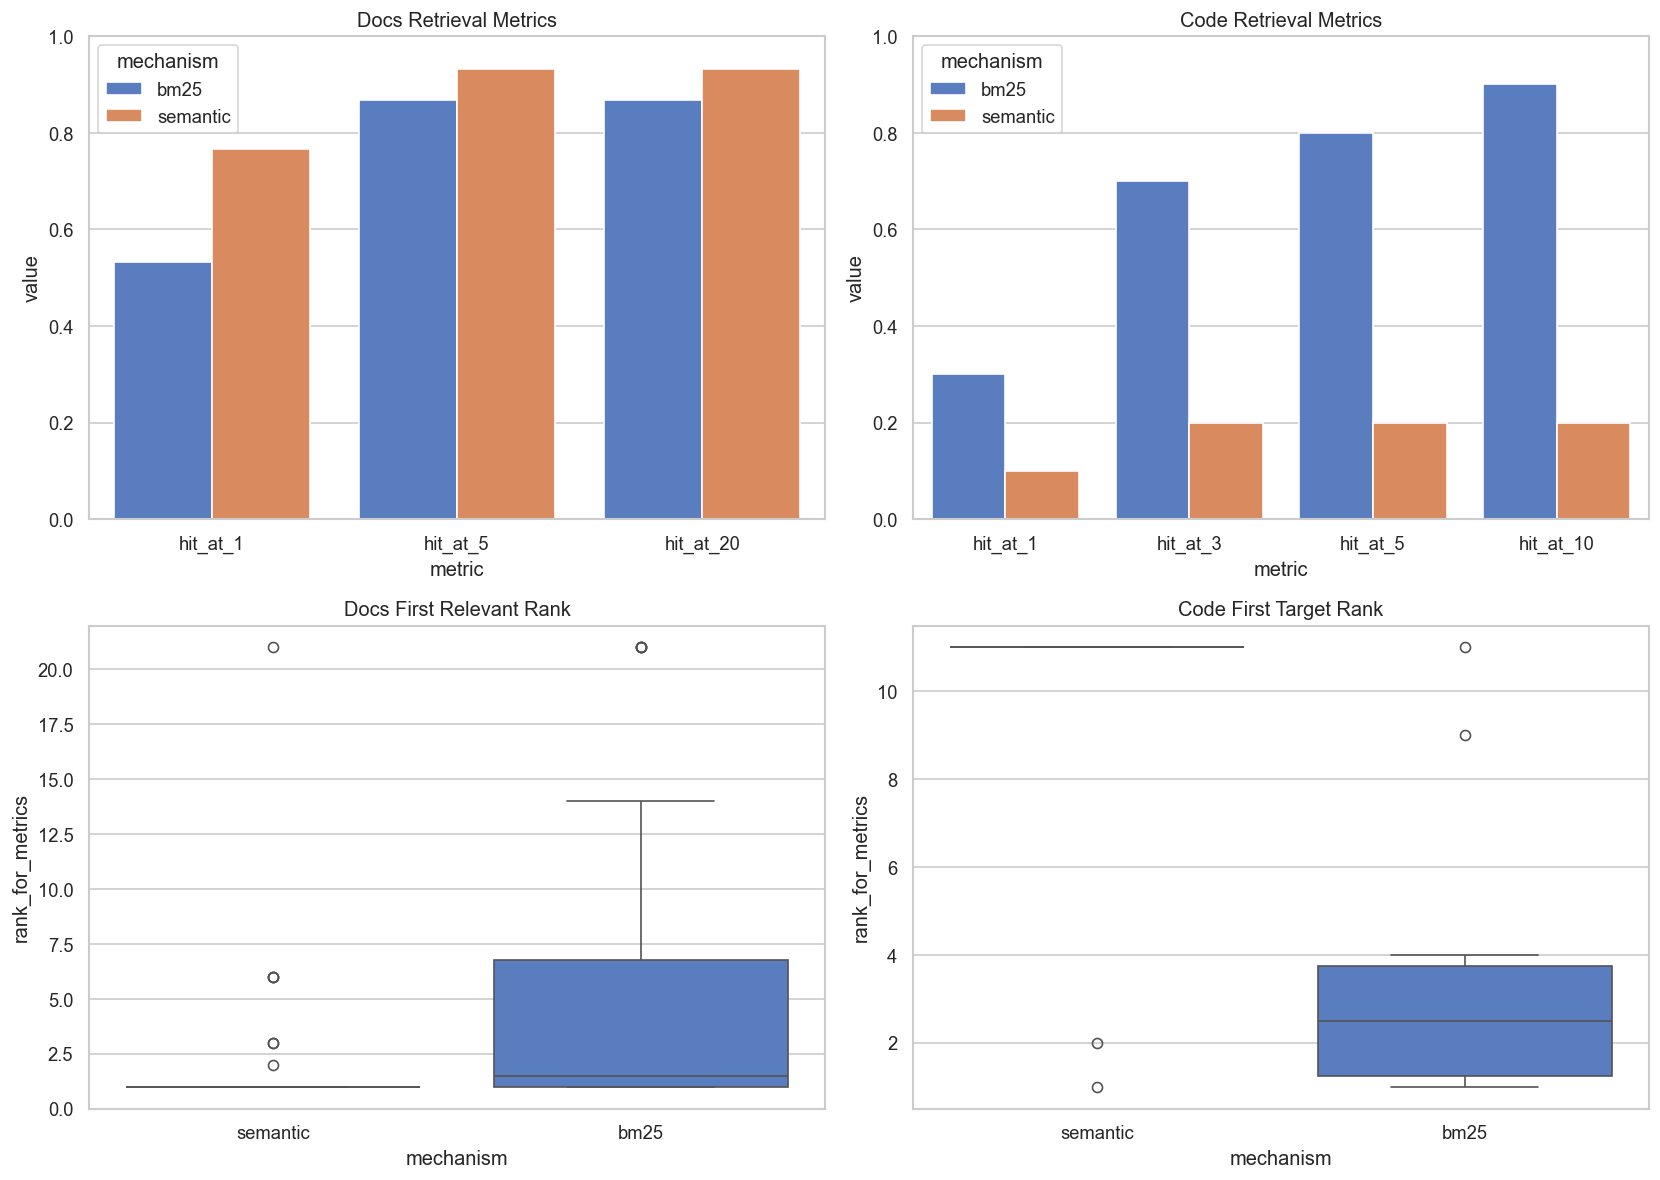

Docs: semantic worse than BM25 on positive delta


,question_id,bm25,semantic,delta,difficulty,question
1,2,1.0,21.0,20.0,Easy,What is the main goal of the Kalisio Developme...
3,4,1.0,6.0,5.0,Easy,Where can users join the Kalisio community chat?
0,1,3.0,6.0,3.0,Easy,What does KDK stand for?
23,24,4.0,6.0,2.0,Hard,Why is the service layer important for decoupl...
12,13,1.0,2.0,1.0,Medium,How does KDK represent business data internally?
4,5,1.0,1.0,0.0,Easy,Under which NPM namespace are KDK modules publ...
10,11,1.0,1.0,0.0,Medium,Why does KDK promote a microservice-based plat...
7,8,1.0,1.0,0.0,Easy,Where can contributors report a bug for KDK?
9,10,3.0,3.0,0.0,Easy,What is shown in the KDK global architecture o...
8,9,1.0,1.0,0.0,Easy,What does the Guides section help developers l...


Code: semantic worse than BM25 on positive delta


,question_id,bm25,semantic,delta,question
6,7,1.0,11.0,10.0,Where is makeDiacriticPattern implemented?
5,6,1.0,11.0,10.0,Which file defines addQueryParameter and URL-b...
7,8,1.0,11.0,10.0,Which file defines the GeoTiffGridSource class?
2,3,2.0,11.0,9.0,Where is getServicePath implemented?
3,4,2.0,11.0,9.0,Which file defines the map defineUserAbilities...
9,10,3.0,11.0,8.0,Which file implements the useHighlight composa...
4,5,4.0,11.0,7.0,Where is the useWeather composable implemented?
8,9,11.0,11.0,0.0,Where are PMTiles layers and related schema he...
1,2,3.0,1.0,-2.0,Which file defines createOfflineService for cl...
0,1,9.0,2.0,-7.0,Where is createService implemented on the clie...


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
docs_plot = docs_metrics.reset_index()[['mechanism', 'hit_at_1', 'hit_at_5', 'hit_at_20']].melt(id_vars='mechanism', var_name='metric', value_name='value')
sns.barplot(data=docs_plot, x='metric', y='value', hue='mechanism', ax=axes[0, 0])
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title('Docs Retrieval Metrics')
code_plot = code_metrics.reset_index()[['mechanism', 'hit_at_1', 'hit_at_3', 'hit_at_5', 'hit_at_10']].melt(id_vars='mechanism', var_name='metric', value_name='value')
sns.barplot(data=code_plot, x='metric', y='value', hue='mechanism', ax=axes[0, 1])
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title('Code Retrieval Metrics')
sns.boxplot(data=docs_eval_df, x='mechanism', y='rank_for_metrics', ax=axes[1, 0])
axes[1, 0].set_title('Docs First Relevant Rank')
sns.boxplot(data=code_eval_df, x='mechanism', y='rank_for_metrics', ax=axes[1, 1])
axes[1, 1].set_title('Code First Target Rank')
plt.tight_layout()
plt.show()

docs_compare = docs_eval_df.pivot(index='question_id', columns='mechanism', values='rank_for_metrics').reset_index()
docs_compare['delta'] = docs_compare['semantic'] - docs_compare['bm25']
docs_compare = docs_compare.merge(pd.DataFrame(questions)[['question_id', 'difficulty', 'question']], on='question_id', how='left')
print('Docs: semantic worse than BM25 on positive delta')
display(docs_compare.sort_values('delta', ascending=False).head(10))

code_compare = code_eval_df.pivot(index='question_id', columns='mechanism', values='rank_for_metrics').reset_index()
code_compare['delta'] = code_compare['semantic'] - code_compare['bm25']
code_compare = code_compare.merge(pd.DataFrame(code_benchmark)[['question_id', 'question']], on='question_id', how='left')
print('Code: semantic worse than BM25 on positive delta')
display(code_compare.sort_values('delta', ascending=False))


## Reading the Outcome

Typical expectations:

- Docs: BM25 should help on acronym, exact-term, and title-heavy fact questions
- Code: BM25 should help on exact symbol and file-responsibility lookups
- If BM25 wins on exact lookup while semantic wins on conceptual questions, the next production step is hybrid retrieval rather than choosing only one mechanism
